# BITB Price Direction Prediction — Improved Model
- Made on May 10th, 2026 
- This notebook improves prediction of BITB returns from the last notebook made
- Switched target from *return magnitude* → *direction* (classification)
- Added BTC-USD as a feature (BITB is a Bitcoin ETF — BTC is the strongest signal)
- Added RSI, price-vs-MA20, and OHLC-based range features
- Kept all original features but also added `ma10`
- Switched model to GradientBoostingClassifier (much stronger than LinearRegression)
- Added walk-forward cross-validation (TimeSeriesSplit)
- Added feature importance chart
- Added proper precision/recall/F1 evaluation

In [18]:

%pip install yfinance pandas "numpy<2" scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [19]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import TimeSeriesSplit

# GradientBoostingClassifier
#   --> Builds many small decision trees one after another.
#   --> Each tree tries to fix the mistakes made by the previous one.
#   --> Much more powerful than linear regression for messy, non-linear data.
#   --> n_estimators = how many trees, max_depth = how complex each tree is.

# TimeSeriesSplit
#   --> A special kind of cross-validation that respects time order.
#   --> Instead of one 80/20 split, it makes 5 rolling train/test windows.
#   --> Gives a more reliable estimate of real-world performance.

print('Imports OK')

Imports OK


In [ ]:

ticker = 'BITB'
df = yf.Ticker(ticker).history(period='max')
df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

print(f'Downloaded {len(df)} rows of BITB data')
df.head()

Downloaded 583 rows of BITB data


,Open,High,Low,Close,Volume
Date,,,,,
2024-01-11 00:00:00-05:00,26.799999,28.500000,25.41,25.540001,4781900
2024-01-12 00:00:00-05:00,25.530001,25.530001,23.82,23.959999,3270000
2024-01-16 00:00:00-05:00,23.770000,23.872999,23.02,23.719999,2224500
2024-01-17 00:00:00-05:00,23.520000,23.580000,23.08,23.400000,1956000
2024-01-18 00:00:00-05:00,23.400000,23.400000,22.23,22.340000,2856900


In [ ]:

# BITB is a Bitcoin ETF, so BTC's own price movement is the single strongest
# predictor of where BITB goes next.

btc_raw = yf.Ticker('BTC-USD').history(period='max')[['Close']]
btc_raw.index = btc_raw.index.tz_convert('America/New_York').normalize()
# Normalize so the index is midnight — makes it easier to join to df

btc_raw['btc_return'] = btc_raw['Close'].pct_change()
# BTC daily return

print(f'Downloaded {len(btc_raw)} rows of BTC-USD data')
btc_raw.tail()

Downloaded 4254 rows of BTC-USD data


,Close,btc_return
Date,,
2026-05-05 00:00:00-04:00,81427.531250,0.006184
2026-05-06 00:00:00-04:00,80009.992188,-0.017409
2026-05-07 00:00:00-04:00,80186.765625,0.002209
2026-05-08 00:00:00-04:00,80664.367188,0.005956
2026-05-09 00:00:00-04:00,81387.750000,0.008968


In [ ]:

df['return'] = df['Close'].pct_change()
# pct_change() computes (today - yesterday) / yesterday
# Result is a fraction, e.g. 0.03 = +3%

df = df.dropna(subset=['return'])
print(df['return'].describe())

count    582.000000
mean       0.001417
std        0.031671
min       -0.144157
25%       -0.017685
50%       -0.000585
75%        0.020573
max        0.133397
Name: return, dtype: float64


In [ ]:

def compute_rsi(series, window=14):
    """
    Relative Strength Index (RSI)
    --------------------------------
    RSI measures whether an asset is overbought (>70) or oversold (<30).
    Formula:
        RSI = 100 - 100 / (1 + RS)
        RS  = avg_gain / avg_loss  over the last `window` days
    We shift(1) at the end so today's RSI only uses past data (no lookahead).
    """
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(window).mean()
    loss  = -delta.clip(upper=0).rolling(window).mean()
    rs    = gain / loss
    rsi   = 100 - (100 / (1 + rs))
    return rsi.shift(1)  # shift so no lookahead leak

print('RSI function defined')

RSI function defined


In [ ]:

# All features are shift(1) so they only contain information from BEFORE today.
# This is critical — using today's data to predict today's return is cheating.

# --- Original features (kept from v1) ---
df['r_lag1']  = df['return'].shift(1)                          # yesterday's return
df['ma5']     = df['return'].rolling(5).mean().shift(1)        # 5-day avg return
df['ma10']    = df['return'].rolling(10).mean().shift(1)       # 10-day avg return (was computed but unused in v1)
df['vol5']    = df['return'].rolling(5).std().shift(1)         # 5-day volatility
df['vol10']   = df['return'].rolling(10).std().shift(1)        # 10-day volatility
df['vol_avg10'] = df['Volume'].rolling(10).mean().shift(1)
df['vol_ratio'] = df['Volume'] / df['vol_avg10']               # volume vs 10-day avg


# RSI: overbought/oversold momentum indicator
df['rsi'] = compute_rsi(df['Close'], window=14)

# Price relative to its 20-day moving average
# > 1.0 means price is above trend (bullish), < 1.0 means below trend (bearish)
df['price_to_ma20'] = (df['Close'] / df['Close'].rolling(20).mean()).shift(1)

# Daily range as fraction of close: how wide was yesterday's candle?
# Big range = high uncertainty
df['range_pct'] = ((df['High'] - df['Low']) / df['Close']).shift(1)

# Gap: did the stock open higher or lower than yesterday's close?
df['gap'] = (df['Open'] / df['Close'].shift(1) - 1).shift(1)

# --- BTC features ---
# Align BTC data to BITB dates
df.index = df.index.tz_convert('America/New_York').normalize()
df = df.join(btc_raw[['btc_return']], how='left')

df['btc_r_lag1'] = df['btc_return'].shift(1)           # BTC yesterday return
df['btc_ma5']    = df['btc_return'].rolling(5).mean().shift(1)   # BTC 5-day trend

# Drop rows with any NaN from rolling windows / joins
df = df.dropna()

print(f'Feature engineering complete. Dataset size: {len(df)} rows')
df[['return', 'r_lag1', 'rsi', 'btc_r_lag1', 'price_to_ma20']].tail()

Feature engineering complete. Dataset size: 562 rows


,return,r_lag1,rsi,btc_r_lag1,price_to_ma20
Date,,,,,
2026-05-04 00:00:00-04:00,0.020897,0.026760,65.021928,0.006117,1.045423
2026-05-05 00:00:00-04:00,0.019319,0.020897,66.456357,0.013769,1.059971
2026-05-06 00:00:00-04:00,-0.002256,0.019319,67.907440,0.006184,1.071502
2026-05-07 00:00:00-04:00,-0.015830,-0.002256,66.632866,-0.017409,1.062049
2026-05-08 00:00:00-04:00,0.000460,-0.015830,57.598298,0.002209,1.039817


In [ ]:

# Instead of predicting the exact return (hard), we predict whether
# tomorrow goes UP (1) or DOWN (0). This is a classification problem.
#
# Why is this better?
#   - Daily return magnitude is nearly impossible to predict precisely.
#   - Direction is what actually matters for trading decisions.
#   - Classification models (like GradientBoosting) handle this much better
#     than linear regression.

df['target'] = (df['return'] > 0).astype(int)
# 1 = price went up today
# 0 = price went down today

print('Class balance (0=down, 1=up):')
print(df['target'].value_counts(normalize=True).round(3))
# Ideally this is close to 50/50 — if very imbalanced we'd need to address that

Class balance (0=down, 1=up):
target
0    0.511
1    0.489
Name: proportion, dtype: float64


In [ ]:

# Same 80/20 time-ordered split as v1.
# We keep this for the final evaluation, and use TimeSeriesSplit for CV.

FEATURES = [
    # Original
    'r_lag1', 'ma5', 'ma10', 'vol5', 'vol10', 'vol_ratio',
    # New
    'rsi', 'price_to_ma20', 'range_pct', 'gap',
    # BTC
    'btc_r_lag1', 'btc_ma5'
]

train_size = int(len(df) * 0.8)
train_df   = df.iloc[:train_size]
test_df    = df.iloc[train_size:]

print(f'Train: {len(train_df)} rows | Test: {len(test_df)} rows')

scaler  = StandardScaler()
X_train = scaler.fit_transform(train_df[FEATURES])
X_test  = scaler.transform(test_df[FEATURES])
y_train = train_df['target'].values
y_test  = test_df['target'].values

# Full arrays for cross-validation
X_all   = scaler.fit_transform(df[FEATURES])
y_all   = df['target'].values

Train: 449 rows | Test: 113 rows


In [ ]:

# TimeSeriesSplit creates 5 expanding windows:
#   Fold 1: train on rows 0-100,  test on 101-200
#   Fold 2: train on rows 0-200,  test on 201-300
#   ... etc.
# This is much more realistic than a single split and shows how the model
# performs across different market regimes.

tscv = TimeSeriesSplit(n_splits=5)

models = {
    'Logistic Regression':     LogisticRegression(max_iter=1000, C=0.1),
    'Random Forest':           RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42),
    'Gradient Boosting':       GradientBoostingClassifier(n_estimators=150, max_depth=3,
                                                          learning_rate=0.05, random_state=42),
}
# Logistic Regression: linear classifier (strong baseline, interpretable)
# Random Forest: builds many independent trees and averages them (reduces overfitting)
# Gradient Boosting: builds trees sequentially, each fixing prior errors (usually best)

cv_results = {}

for name, m in models.items():
    fold_scores = []
    for train_idx, val_idx in tscv.split(X_all):
        m.fit(X_all[train_idx], y_all[train_idx])
        preds = m.predict(X_all[val_idx])
        fold_scores.append(accuracy_score(y_all[val_idx], preds))
    cv_results[name] = fold_scores
    print(f'{name:28s}  CV acc: {np.mean(fold_scores):.3f} ± {np.std(fold_scores):.3f}')

Logistic Regression           CV acc: 0.796 ± 0.033
Random Forest                 CV acc: 0.796 ± 0.038
Gradient Boosting             CV acc: 0.759 ± 0.020


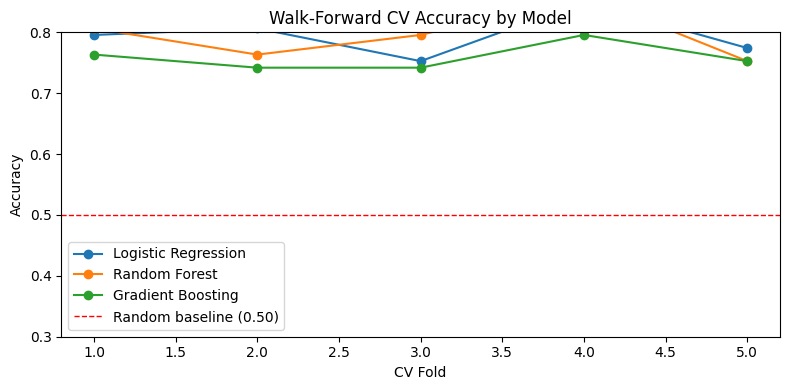

In [ ]:

fig, ax = plt.subplots(figsize=(8, 4))
for name, scores in cv_results.items():
    ax.plot(range(1, 6), scores, marker='o', label=name)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Random baseline (0.50)')
ax.set_xlabel('CV Fold')
ax.set_ylabel('Accuracy')
ax.set_title('Walk-Forward CV Accuracy by Model')
ax.legend()
ax.set_ylim(0.3, 0.8)
plt.tight_layout()
plt.show()

In [ ]:

# Re-train each model on the full training set and evaluate on the test set.

print('=' * 60)
print('FINAL EVALUATION ON HELD-OUT TEST SET')
print('=' * 60)

best_model = None
best_acc   = 0

for name, m in models.items():
    m.fit(X_train, y_train)
    preds = m.predict(X_test)
    acc   = accuracy_score(y_test, preds)
    print(f'\n--- {name} ---')
    print(f'Accuracy: {acc:.3f}')
    print(classification_report(y_test, preds, target_names=['Down', 'Up']))
    # Precision: when we predict Up, how often are we right?
    # Recall: of all actual Up days, how many did we catch?
    # F1: harmonic mean of precision and recall
    if acc > best_acc:
        best_acc   = acc
        best_model = (name, m)

FINAL EVALUATION ON HELD-OUT TEST SET

--- Logistic Regression ---
Accuracy: 0.770
              precision    recall  f1-score   support

        Down       0.80      0.75      0.77        59
          Up       0.74      0.80      0.77        54

    accuracy                           0.77       113
   macro avg       0.77      0.77      0.77       113
weighted avg       0.77      0.77      0.77       113


--- Random Forest ---
Accuracy: 0.770
              precision    recall  f1-score   support

        Down       0.77      0.80      0.78        59
          Up       0.77      0.74      0.75        54

    accuracy                           0.77       113
   macro avg       0.77      0.77      0.77       113
weighted avg       0.77      0.77      0.77       113


--- Gradient Boosting ---
Accuracy: 0.788
              precision    recall  f1-score   support

        Down       0.79      0.81      0.80        59
          Up       0.79      0.76      0.77        54

    accuracy     

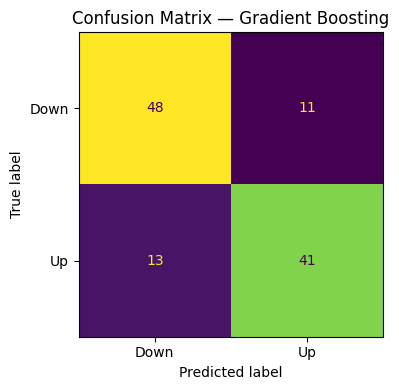

In [ ]:

# Shows the breakdown of correct and incorrect predictions.
# Rows = actual class, Columns = predicted class.

name, best = best_model
preds = best.predict(X_test)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, preds),
    display_labels=['Down', 'Up']
).plot(ax=ax, colorbar=False)
ax.set_title(f'Confusion Matrix — {name}')
plt.tight_layout()
plt.show()

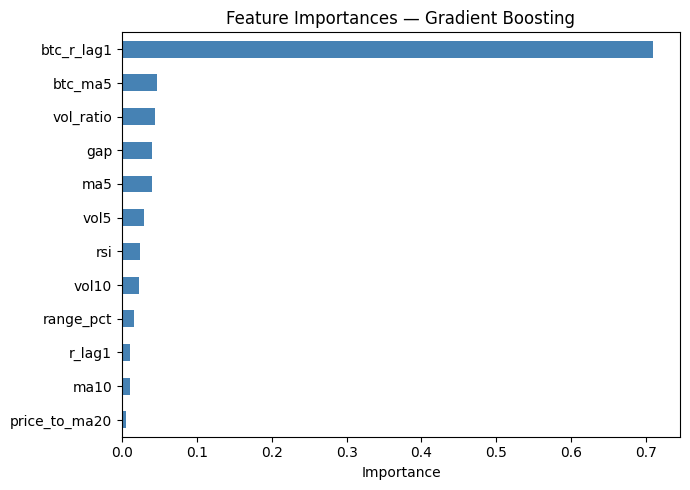

In [ ]:

# Which features does the best model rely on most?
# Higher importance = that feature is more useful for predicting direction.
# If btc_r_lag1 ranks highly, it confirms BTC drives BITB.

name, best = best_model

if hasattr(best, 'feature_importances_'):
    imp = pd.Series(best.feature_importances_, index=FEATURES).sort_values()
    fig, ax = plt.subplots(figsize=(7, 5))
    imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Feature Importances — {name}')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    # Logistic regression uses coefficients instead
    coef = pd.Series(best.coef_[0], index=FEATURES).sort_values()
    fig, ax = plt.subplots(figsize=(7, 5))
    coef.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Coefficients — {name}')
    ax.set_xlabel('Coefficient value')
    plt.tight_layout()
    plt.show()

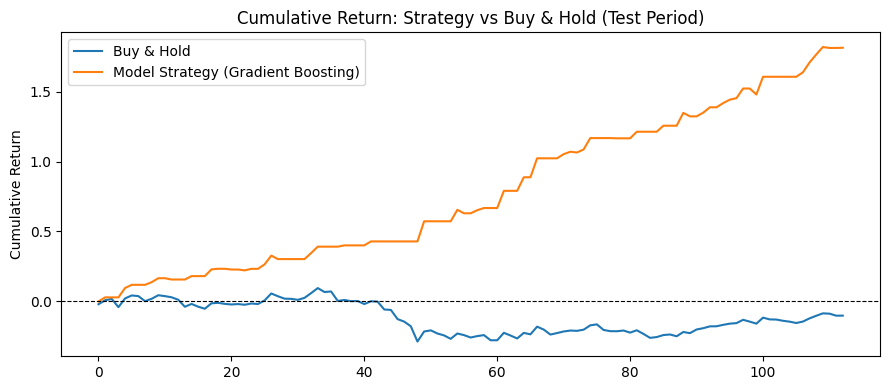

Buy & Hold total return:  -10.1%
Strategy total return:    181.3%

Note: This simulation ignores transaction costs and slippage.
Real-world performance would be lower.


In [ ]:

# Simulate a simple strategy: go long (+1) on days we predict Up,
# stay flat (0) on days we predict Down.
# Compare to buy-and-hold.

name, best = best_model
preds      = best.predict(X_test)

test_returns = test_df['return'].values

strategy_returns  = preds * test_returns       # only in market when we predict Up
bh_cumulative     = np.cumprod(1 + test_returns) - 1
strat_cumulative  = np.cumprod(1 + strategy_returns) - 1

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(bh_cumulative, label='Buy & Hold', linewidth=1.5)
ax.plot(strat_cumulative, label=f'Model Strategy ({name})', linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Cumulative Return: Strategy vs Buy & Hold (Test Period)')
ax.set_ylabel('Cumulative Return')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Buy & Hold total return:  {bh_cumulative[-1]*100:.1f}%')
print(f'Strategy total return:    {strat_cumulative[-1]*100:.1f}%')
print()
print('Note: This simulation ignores transaction costs and slippage.')
print('Real-world performance would be lower.')

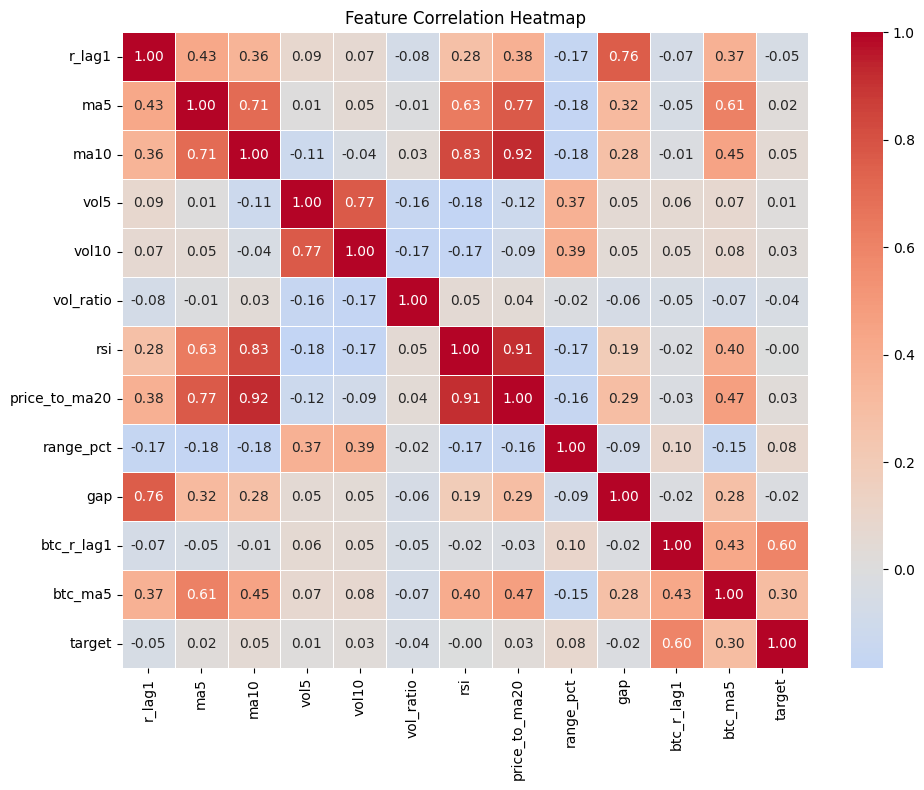

In [ ]:

# Check how features correlate with each other and with the target.
# Highly correlated feature pairs (>0.85) might be redundant — you can drop one.

corr = df[FEATURES + ['target']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax
)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()